In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans


In [65]:
# import data
banking_marketing_train_original = pd.read_csv('banking_marketing_train.csv', delimiter=';', quotechar='"')
banking_marketing_test_original = pd.read_csv('banking_marketing_test.csv', delimiter=';', quotechar='"')

In [239]:
# import data
banking_marketing_train = pd.read_csv('banking_marketing_train.csv', delimiter=';', quotechar='"')
banking_marketing_test = pd.read_csv('banking_marketing_test.csv', delimiter=';', quotechar='"')

# data cleaning

In [10]:
banking_marketing_train.info()
banking_marketing_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [11]:
# check for missing values
banking_marketing_train.isna().sum()

# no na

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
# check for duplicate rows
banking_marketing_train.duplicated().sum()

# no duplicate rows

0

In [13]:
banking_marketing_train.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [14]:
# convert columns with number to numeric
numeric_columns = ['age','balance','day','duration','campaign','pdays','previous']
for col in numeric_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")

Category counts for column 'age':
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
93       2
90       2
95       2
88       2
94       1
Name: age, Length: 77, dtype: int64


Category counts for column 'balance':
 0        3514
 1         195
 2         156
 4         139
 3         134
          ... 
-381         1
 4617        1
 20584       1
 4358        1
 16353       1
Name: balance, Length: 7168, dtype: int64


Category counts for column 'day':
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
19    1757
29    1745
15    1703
12    1603
13    1585
30    1566
9     1561
11    1479
4     1445
16    1415
2     1293
27    1121
3     1079
26    1035
23     939
22     905
25     840
31     643
10     524
24     447
1      322
Name: day, dtype: int64


Category counts for column 'duration':
124     188
90      184
89      177
104     175
122     175
       ... 
1833      1
1545      1
1352      1
1342      1


In [15]:
banking_marketing_train.select_dtypes(include=['number'])

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


encoding

In [16]:
banking_marketing_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# feature engineering - encoding

In [240]:
banking_marketing_train_encoded = banking_marketing_train
banking_marketing_test_encoded = banking_marketing_test

In [241]:
# yes/no
binary_columns = ['default','housing','loan','y']
for col in binary_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
for column in binary_columns:
    banking_marketing_train_encoded[column] = banking_marketing_train[column].map({'yes': 1, 'no': 0})
    banking_marketing_test_encoded[column] = banking_marketing_test[column].map({'yes': 1, 'no': 0})


Category counts for column 'default':
no     44396
yes      815
Name: default, dtype: int64


Category counts for column 'housing':
yes    25130
no     20081
Name: housing, dtype: int64


Category counts for column 'loan':
no     37967
yes     7244
Name: loan, dtype: int64


Category counts for column 'y':
no     39922
yes     5289
Name: y, dtype: int64




In [242]:
# nominal
nominal_columns = ['job','marital','contact','poutcome']
for col in nominal_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
banking_marketing_train_encoded = pd.get_dummies(banking_marketing_train, columns=nominal_columns)
banking_marketing_test_encoded = pd.get_dummies(banking_marketing_test, columns=nominal_columns)

Category counts for column 'job':
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: job, dtype: int64


Category counts for column 'marital':
married     27214
single      12790
divorced     5207
Name: marital, dtype: int64


Category counts for column 'contact':
cellular     29285
unknown      13020
telephone     2906
Name: contact, dtype: int64


Category counts for column 'poutcome':
unknown    36959
failure     4901
other       1840
success     1511
Name: poutcome, dtype: int64




create a special column for poutcome, success = 1, failure = 0, filter other columns 
special_train = banking_marketing_train[banking_marketing_train['poutcome']]

In [243]:
# ordinal
ordinal_columns = ['education','month']
encoder = LabelEncoder()
for col in ordinal_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
    banking_marketing_train_encoded[col] = encoder.fit_transform(banking_marketing_train[col])
    banking_marketing_test_encoded[col] = encoder.fit_transform(banking_marketing_test[col])



Category counts for column 'education':
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: education, dtype: int64


Category counts for column 'month':
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: month, dtype: int64




In [219]:
banking_marketing_train_encoded.head()
banking_marketing_train_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

In [244]:
banking_marketing_test_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

# data visualisation

plt.figure(1, figsize=(16,10))
sns.pairplot(data=banking_marketing_train_encoded, hue='y')
plt.show()

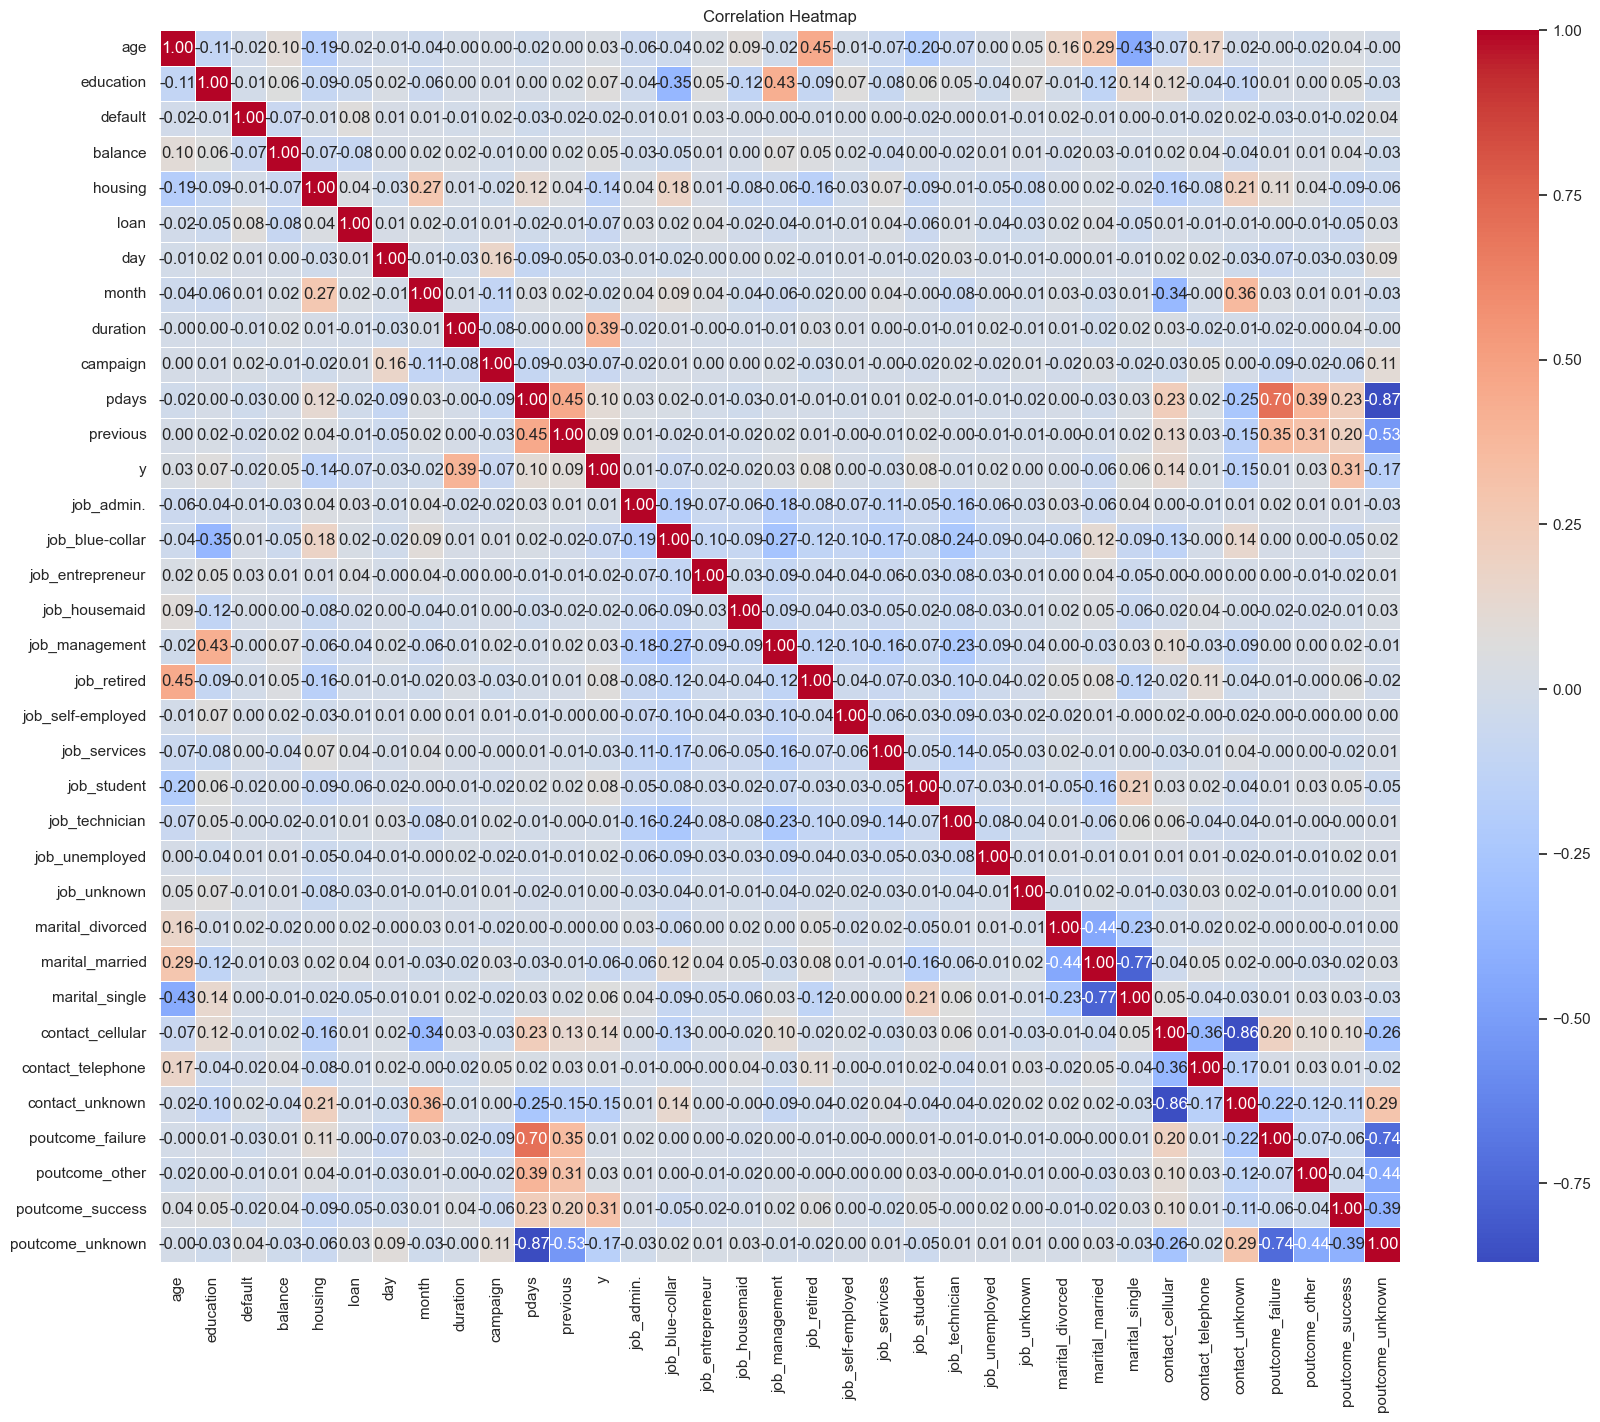

In [98]:
# plot Correlation Heatmap

# Compute correlation matrix
corr_matrix = banking_marketing_train_encoded.corr()

# Plot heatmap
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# association with y
# > 0.1, duration, pdays, contact_cellular,poutcome_success,poutcome_other
# negative, housing, contact_unknown, poutcome_unknown
# 0, job = self-employed

# association with poutcome-success
# > 0.1, pdays, previous, contact_cellular
# negative, contact_unknown

poutcome and previous - for previous campaigns, is there a relationship between number of tries and success rate

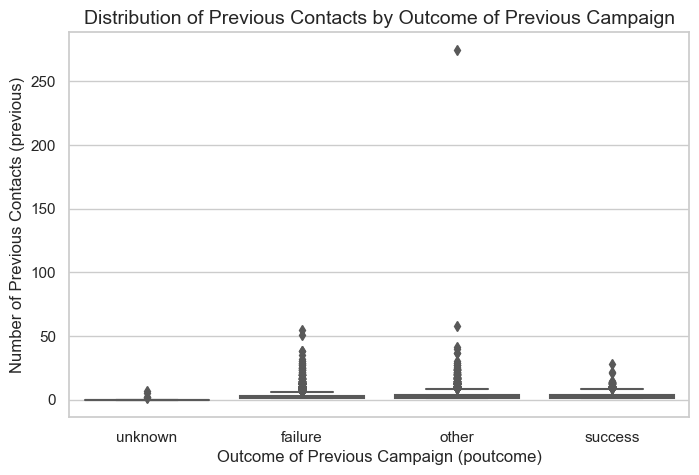

In [75]:
# Set the plot style
sns.set(style="whitegrid")

# Create a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='poutcome', y='previous', data=banking_marketing_train, palette="Set2")

# Add title and labels
plt.title("Distribution of Previous Contacts by Outcome of Previous Campaign", fontsize=14)
plt.xlabel("Outcome of Previous Campaign (poutcome)")
plt.ylabel("Number of Previous Contacts (previous)")

# Show the plot
plt.show()

pdays and y

In [76]:
print('-1 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==-1]['y'].value_counts())
print('182 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==182]['y'].value_counts())
print('92 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==92]['y'].value_counts())
print('91 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==91]['y'].value_counts())
print('183 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==183]['y'].value_counts())

-1 

0    33570
1     3384
Name: y, dtype: int64
182 

0    87
1    80
Name: y, dtype: int64
92 

1    96
0    51
Name: y, dtype: int64
91 

1    75
0    51
Name: y, dtype: int64
183 

1    64
0    62
Name: y, dtype: int64


0    6352
1    1905
Name: y, dtype: int64


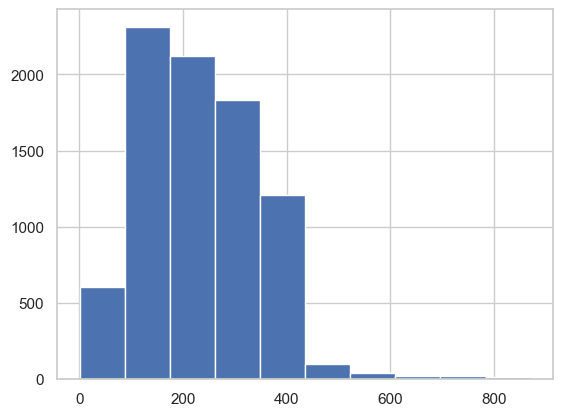

In [77]:
filtered_train = banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']!=-1]
print(filtered_train['y'].value_counts())
# if not previously contacted, much higher probability of failure

filtered_train['pdays'].hist()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


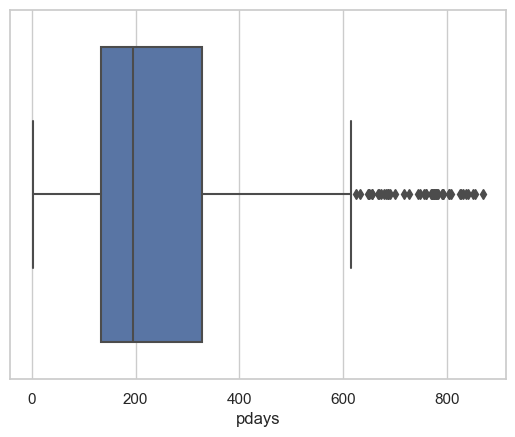

In [78]:
sns.boxplot(filtered_train['pdays'])
plt.show()

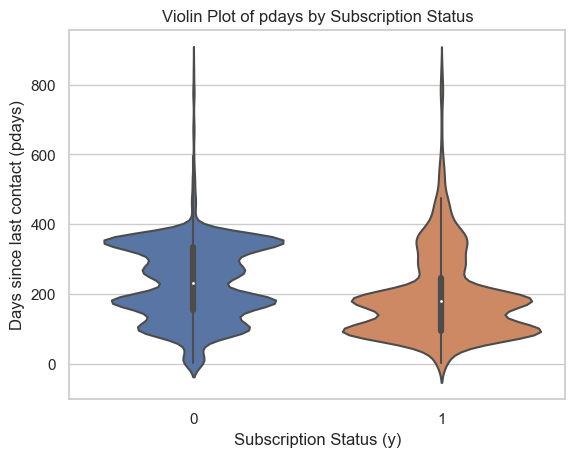

In [79]:
# Create a violin plot for duration and y
sns.violinplot(x='y', y='pdays', data=filtered_train)
plt.title('Violin Plot of pdays by Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()


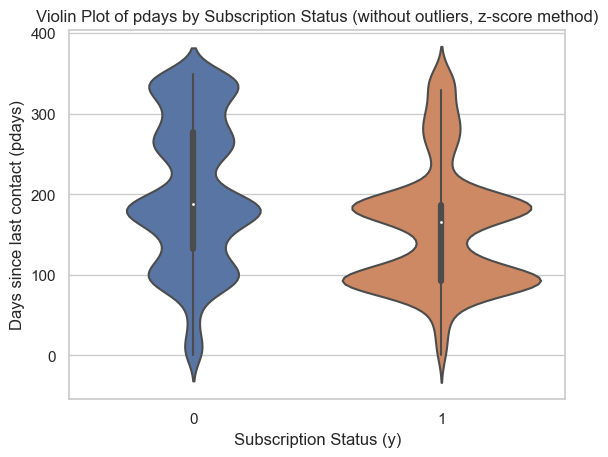

In [80]:
from scipy.stats import zscore

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = filtered_train[filtered_train['pdays']<350]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='pdays', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of pdays by Subscription Status (without outliers, z-score method)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()


the plot shows that smaller pdays -> higher succes rate


In [81]:
# duration with y
banking_marketing_train_encoded['duration'].value_counts()

124     188
90      184
89      177
104     175
122     175
       ... 
1833      1
1545      1
1352      1
1342      1
1556      1
Name: duration, Length: 1573, dtype: int64

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


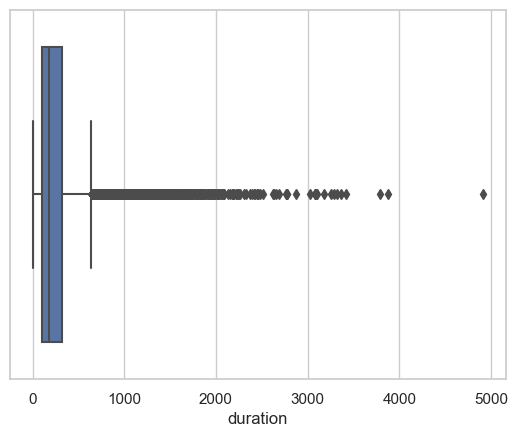

In [82]:
sns.boxplot(banking_marketing_train_encoded['duration'])
plt.show()

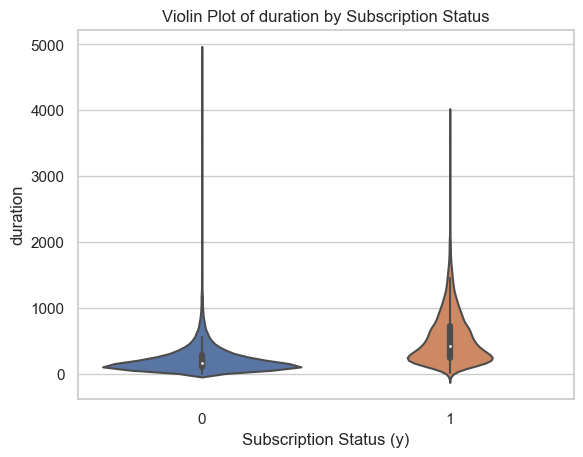

In [83]:
# Create a violin plot for duration and y
sns.violinplot(x='y', y='duration', data=banking_marketing_train_encoded)
plt.title('Violin Plot of duration by Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('duration')
plt.show()


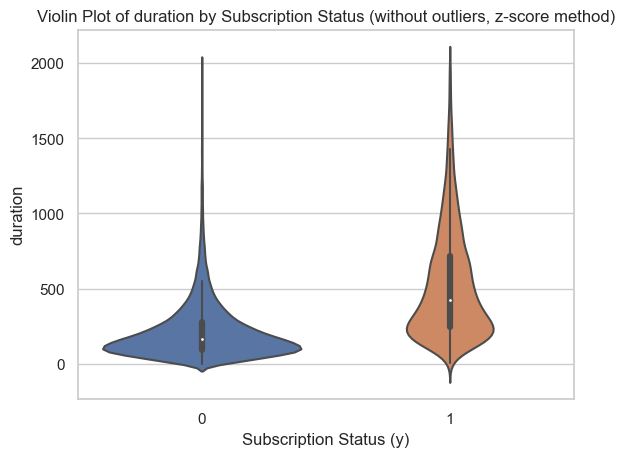

In [84]:

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = banking_marketing_train_encoded[banking_marketing_train_encoded['duration']<2000]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='duration', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of duration by Subscription Status (without outliers, z-score method)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('duration')
plt.show()


smaller duration -> low success rate

In [85]:
# previous and y
banking_marketing_train_encoded['previous'].value_counts()

0      36954
1       2772
2       2106
3       1142
4        714
5        459
6        277
7        205
8        129
9         92
10        67
11        65
12        44
13        38
15        20
14        19
17        15
16        13
19        11
20         8
23         8
18         6
22         6
24         5
27         5
21         4
29         4
25         4
30         3
38         2
37         2
26         2
28         2
51         1
275        1
58         1
32         1
40         1
55         1
35         1
41         1
Name: previous, dtype: int64

In [86]:
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==0]['y'].value_counts())

print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==1]['y'].value_counts())
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==2]['y'].value_counts())
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==3]['y'].value_counts())

0    33570
1     3384
Name: y, dtype: int64
0    2189
1     583
Name: y, dtype: int64
0    1650
1     456
Name: y, dtype: int64
0    848
1    294
Name: y, dtype: int64


0    6352
1    1905
Name: y, dtype: int64


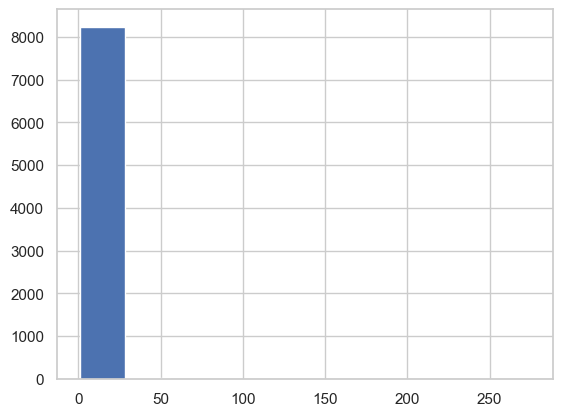

In [87]:
filtered_train = banking_marketing_train_encoded[banking_marketing_train_encoded['previous']!=0]
print(filtered_train['y'].value_counts())
# if not previously contacted, much higher probability of failure

filtered_train['previous'].hist()
plt.show()


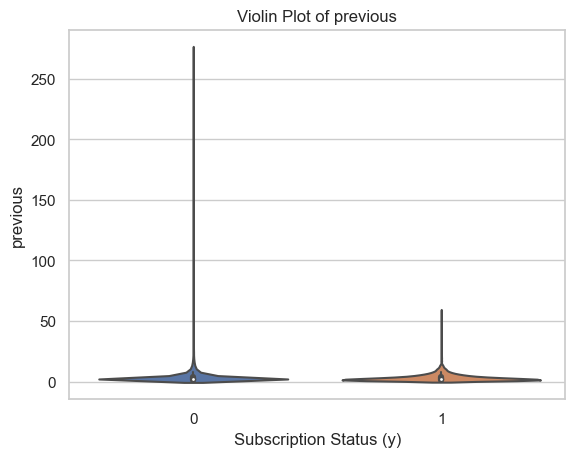

In [88]:
# Create a violin plot for duration and y
sns.violinplot(x='y', y='previous', data=filtered_train)
plt.title('Violin Plot of previous')
plt.xlabel('Subscription Status (y)')
plt.ylabel('previous')
plt.show()


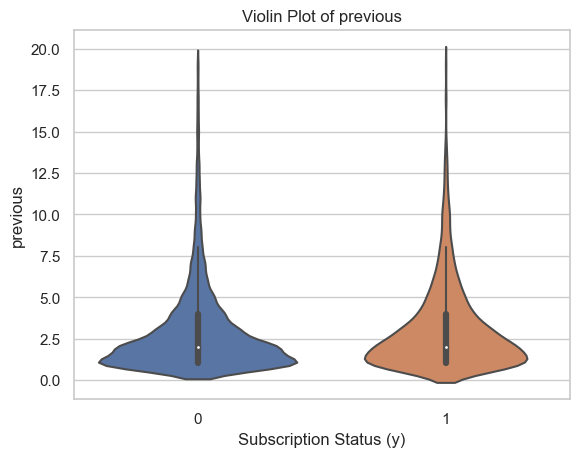

In [89]:
from scipy.stats import zscore

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = filtered_train[filtered_train['previous']<20]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='previous', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of previous')
plt.xlabel('Subscription Status (y)')
plt.ylabel('previous')
plt.show()


In [90]:
# housing and y
banking_marketing_train_encoded['housing'].value_counts()

1    25130
0    20081
Name: housing, dtype: int64

In [91]:

# Assuming 'loan' and 'y' are the two binary columns in the DataFrame
contingency_table = pd.crosstab(banking_marketing_train_encoded['housing'], banking_marketing_train_encoded['y'])

# Display the contingency table
print(contingency_table)


y            0     1
housing             
0        16727  3354
1        23195  1935


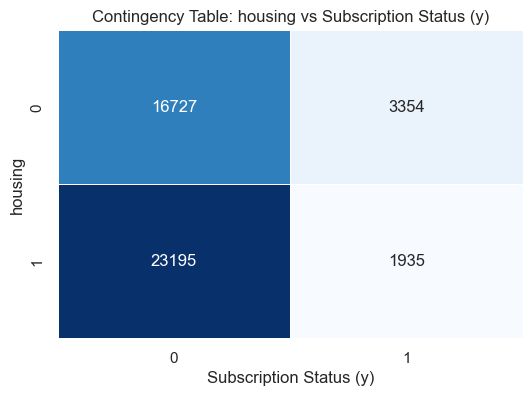

In [92]:

# Plotting the heatmap for the contingency table
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title('Contingency Table: housing vs Subscription Status (y)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('housing')
plt.show()


has housing loan -> low success rate

# feature engineering - create new features

## create a feature: cost
it is related to campaign, duration, contact

treat contact as the same - telemarketing

duration * campaign / 3600 * 38 - us dollar

from this source: https://www.magellan-solutions.com/blog/cost-of-telemarketing/

In [ ]:
# Count the frequency of each unique value in the 'contact' column
contact_counts = banking_marketing_train['contact'].value_counts()

# Display the result
print(contact_counts)

cellular     29285
unknown      13020
telephone     2906
Name: contact, dtype: int64


In [245]:
banking_marketing_train_encoded['cost'] = banking_marketing_train_encoded['duration'] * banking_marketing_train_encoded['campaign'] / 3600 * 38


In [246]:
banking_marketing_test_encoded['cost'] = banking_marketing_test_encoded['duration'] * banking_marketing_test_encoded['campaign'] / 3600 * 38


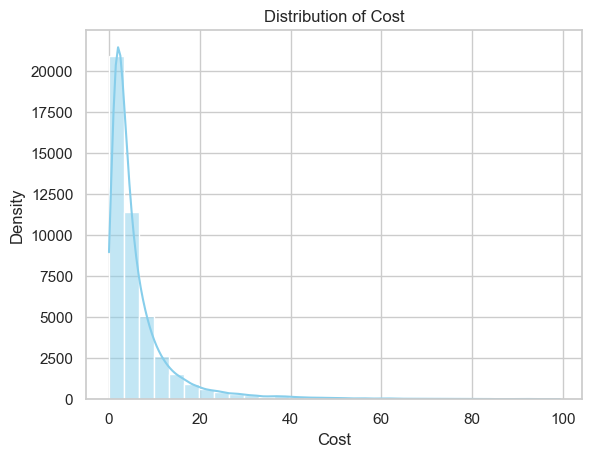

In [247]:
# Drop missing values from 'cost' column (if any) to ensure clean plotting
clean_cost_data = banking_marketing_train_encoded[banking_marketing_train_encoded['cost']<100]['cost'].dropna()

# Plot the distribution of the 'cost' column
sns.histplot(clean_cost_data, kde=True, color='skyblue', bins=30)

# Set plot labels and title
plt.title('Distribution of Cost')
plt.xlabel('Cost')
plt.ylabel('Density')

# Show the plot
plt.show()


## create a feature clv, from q3

In [319]:
## CLV = Customer Lifetime Value = Customer Value x Average Customer Lifespan
# Purchase Frequency 
# using previous and campaign (higher values indicate more engagement)
banking_marketing_train_encoded['purchase_frequency'] = banking_marketing_train_encoded['previous'] / (banking_marketing_train_encoded['previous'] + banking_marketing_train_encoded['campaign'])

# Customer Lifespan
# assume they start working at 25
banking_marketing_train_encoded['customer_lifespan'] = (banking_marketing_train_encoded['age'] - 25) * 365 
banking_marketing_train_encoded['customer_lifespan'] += banking_marketing_train_encoded['pdays'].apply(lambda x: 1 if x == -1 else x)

# Estimate Revenue per Purchase
# Historical success rate: How often y = yes among past engagements.
# avg_revenue_per_purchase from Xinzi 'deposit_amount'
banking_marketing_train_encoded['success_rate'] = banking_marketing_train.groupby('job')['y'].transform(lambda x: x.eq('yes').mean())
banking_marketing_train_encoded['avg_revenue'] = banking_marketing_train_encoded['success_rate'] * banking_marketing_train_encoded['balance']

# calculate CLV
banking_marketing_train_encoded['CLV'] = banking_marketing_train_encoded['purchase_frequency'] * banking_marketing_train_encoded['customer_lifespan'] * banking_marketing_train_encoded['avg_revenue']

# display the first few rows 

In [322]:
## CLV = Customer Lifetime Value = Customer Value x Average Customer Lifespan
# Purchase Frequency 
# using previous and campaign (higher values indicate more engagement)
banking_marketing_test_encoded['purchase_frequency'] = banking_marketing_test_encoded['previous'] / (banking_marketing_test_encoded['previous'] + banking_marketing_train_encoded['campaign'])

# Customer Lifespan
# assume they start working at 25
banking_marketing_test_encoded['customer_lifespan'] = (banking_marketing_test_encoded['age'] - 25) * 365 
banking_marketing_test_encoded['customer_lifespan'] += banking_marketing_test_encoded['pdays'].apply(lambda x: 1 if x == -1 else x)

# Estimate Revenue per Purchase
# Historical success rate: How often y = yes among past engagements.
# avg_revenue_per_purchase from Xinzi 'deposit_amount'
banking_marketing_test_encoded['success_rate'] = banking_marketing_test.groupby('job')['y'].transform(lambda x: x.eq('yes').mean())
banking_marketing_test_encoded['avg_revenue'] = banking_marketing_test_encoded['success_rate'] * banking_marketing_test_encoded['balance']

# calculate CLV
banking_marketing_test_encoded['CLV'] = banking_marketing_test_encoded['purchase_frequency'] * banking_marketing_test_encoded['customer_lifespan'] * banking_marketing_train_encoded['avg_revenue']


In [318]:
banking_marketing_train_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'cost'],
      dtype='object')

# k means clustering for customer segmentation

In [248]:
banking_marketing_train_clustered = banking_marketing_train_encoded
banking_marketing_test_clustered = banking_marketing_test_encoded

In [300]:
# Calculate the mean of each column in the DataFrame
mean_values = banking_marketing_train_encoded.mean()

# Print the mean values
print(mean_values)


age                    40.936210
education               1.224813
default                 0.018027
balance              1362.272058
housing                 0.555838
loan                    0.160226
day                    15.806419
month                   5.523014
duration              258.163080
campaign                2.763841
pdays                  40.197828
previous                0.580323
y                       0.116985
job_admin.              0.114375
job_blue-collar         0.215257
job_entrepreneur        0.032890
job_housemaid           0.027427
job_management          0.209197
job_retired             0.050076
job_self-employed       0.034925
job_services            0.091880
job_student             0.020747
job_technician          0.168034
job_unemployed          0.028820
job_unknown             0.006370
marital_divorced        0.115171
marital_married         0.601933
marital_single          0.282896
contact_cellular        0.647741
contact_telephone       0.064276
contact_un

In [271]:
banking_marketing_test_encoded.isna().sum()

age                  0
education            0
default              0
balance              0
housing              0
loan                 0
day                  0
month                0
duration             0
campaign             0
pdays                0
previous             0
y                    0
job_admin.           0
job_blue-collar      0
job_entrepreneur     0
job_housemaid        0
job_management       0
job_retired          0
job_self-employed    0
job_services         0
job_student          0
job_technician       0
job_unemployed       0
job_unknown          0
marital_divorced     0
marital_married      0
marital_single       0
contact_cellular     0
contact_telephone    0
contact_unknown      0
poutcome_failure     0
poutcome_other       0
poutcome_success     0
poutcome_unknown     0
cost                 0
dtype: int64

In [ ]:
demographic_features = ['age', 'education','job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single']
financial_features = ['default', 'balance', 'housing', 'loan',]
behaviour_features = ['campaign','contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'pdays', 'previous']
columns_for_clustering = demographic_features + financial_features + behaviour_features
print(len(columns_for_clustering))
# columns_for_clustering = banking_marketing_train_encoded.drop(columns = ['y']).columns

# Extract the relevant columns
banking_marketing_train_clustered = banking_marketing_train_clustered[columns_for_clustering]
banking_marketing_test_clustered = banking_marketing_test_clustered[columns_for_clustering]


# Step 3: Handle missing values (if any)
# data_for_clustering = data_for_clustering.fillna(data_for_clustering.mean())

# Step 4: Standardize the data 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(banking_marketing_train_clustered)
data_scaled_test = scaler.fit_transform(banking_marketing_test_clustered)


31


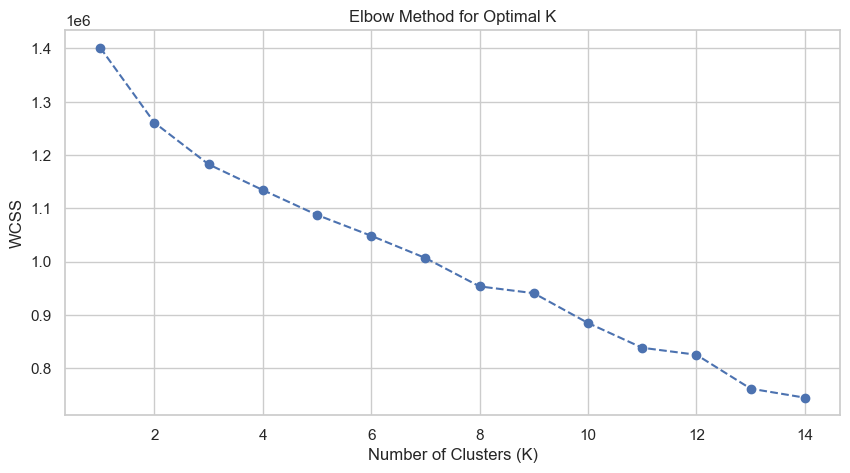

In [251]:
from sklearn.metrics import silhouette_score

# Determine Optimal Number of Clusters 
wcss = []  # Within-cluster sum of squares
silhouette_scores = []
K_range = range(1, 15)  # Start from 2 to avoid error with silhouette score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

    # Compute Silhouette Score
    # labels = kmeans.labels_
    # silhouette_scores.append(silhouette_score(data_scaled, labels))

# Plot the elbow curve
plt.figure(figsize=(10,5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

# Plot Silhouette Scores
# plt.figure(figsize=(10,5))
# plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='green')
# plt.xlabel("Number of Clusters (K)")
# plt.ylabel("Silhouette Score")
# plt.title("Silhouette Score for Optimal K")
# plt.show()

In [106]:
from sklearn.decomposition import PCA

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/2875513237.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered['Cluster'] = kmeans.fit_predict(data_scaled)
/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/2875513237.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered['PCA1'] = pca_result[:, 0]
/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/2875513237.py:17: SettingWithCopyWarning: 
A value

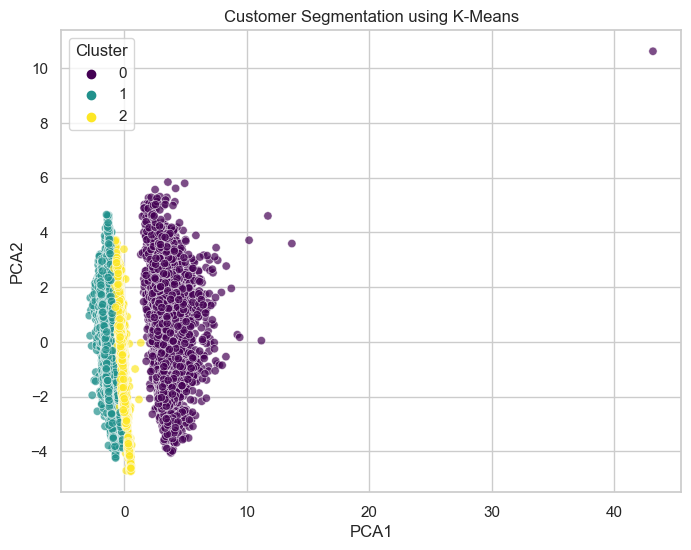

In [252]:
# apply kmeans
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
banking_marketing_train_clustered['Cluster'] = kmeans.fit_predict(data_scaled)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

# Create DataFrame for PCA components with sorted contributions
# pca_df = pd.DataFrame(pca.components_, columns=banking_marketing_train_encoded.drop(columns = ['Cluster']).columns, index=['PCA1', 'PCA2'])

# Sort by the contributions to PCA1
# print(pca_df.T.sort_values(by="PCA1", ascending=False))

banking_marketing_train_clustered['PCA1'] = pca_result[:, 0]
banking_marketing_train_clustered['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x=banking_marketing_train_clustered['PCA1'], y=banking_marketing_train_clustered['PCA2'], hue=banking_marketing_train_clustered['Cluster'], palette='viridis', alpha = 0.7)
plt.title("Customer Segmentation using K-Means")
plt.show()


In [253]:
# Analyze Cluster Characteristics
cluster_summary = banking_marketing_train_clustered.groupby('Cluster').mean()

In [254]:
# Print each row of the summary
for index, row in cluster_summary.iterrows():
    print(f"Cluster {index}:")
    print(row)
    print("\n")


Cluster 0:
age                    40.952750
education               1.276714
job_admin.              0.131815
job_blue-collar         0.195905
job_entrepreneur        0.027260
job_housemaid           0.018415
job_management          0.221105
job_retired             0.059002
job_self-employed       0.034044
job_services            0.085534
job_student             0.034529
job_technician          0.162588
job_unemployed          0.025806
job_unknown             0.003998
marital_divorced        0.112794
marital_married         0.574630
marital_single          0.312576
default                 0.006906
balance              1557.002302
housing                 0.622850
loan                    0.135934
campaign                2.056215
contact_cellular        0.915071
contact_telephone       0.076448
contact_unknown         0.008481
poutcome_failure        0.593773
poutcome_other          0.222922
poutcome_success        0.183063
poutcome_unknown        0.000242
pdays                 224.604313

In [255]:
banking_marketing_train_clustered_with_y = banking_marketing_train_clustered
banking_marketing_train_clustered_with_y['y'] = banking_marketing_train_encoded['y']

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/645723935.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banking_marketing_train_clustered_with_y['y'] = banking_marketing_train_encoded['y']


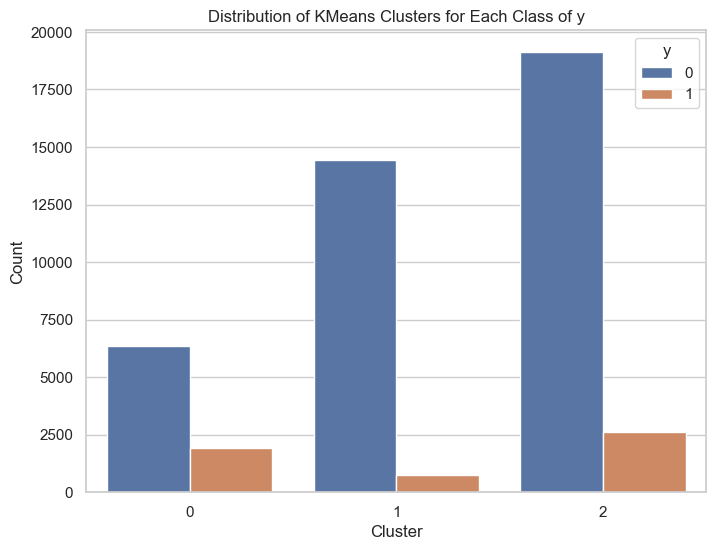

In [256]:
# Assuming 'Cluster' column is in your dataframe with KMeans results
plt.figure(figsize=(8, 6))
sns.countplot(x='Cluster', hue='y', data=banking_marketing_train_clustered_with_y)
plt.title("Distribution of KMeans Clusters for Each Class of y")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [257]:
# Group the data by 'Cluster' and calculate the ratio of 1s in each cluster
cluster_ratios = banking_marketing_train_clustered_with_y.groupby('Cluster')['y'].mean()

# Find the cluster with the highest ratio of 1s
max_cluster = cluster_ratios.idxmax()
max_ratio = cluster_ratios.max()

# Print the result
print(f"Cluster {max_cluster} has the highest ratio of 1s with a ratio of {max_ratio:.4f}")


Cluster 0 has the highest ratio of 1s with a ratio of 0.2306


cluster analysis

Cluster 0: Appears to be a relatively stable group with moderate campaign participation and high financial balances. The higher cellular contact rate suggests good engagement with marketing efforts, though the failure rate is still significant.   -> higher success rate

Cluster 1: Represents a more industrial, blue-collar group with lower balances and more focused telephone contact. This group has a high unknown outcome in campaigns, suggesting low engagement or response.

Cluster 2: Features a balanced mix of job categories and high campaign participation, with 100% cellular contact indicating a more modern, tech-savvy group. This cluster is most likely to have responses marked as unknown in past campaigns.

## validate

In [267]:
test_customers = banking_marketing_test_clustered 

In [262]:
test_customers['y'] = banking_marketing_test_encoded['y']

/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/2200559609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_customers['y'] = banking_marketing_test_encoded['y']


In [269]:
test_customers.columns

Index(['age', 'education', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'default', 'balance', 'housing', 'loan', 'campaign', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'pdays',
       'previous', 'y'],
      dtype='object')

### use kmeans.predict

In [272]:
# Assuming 'kmeans' is the trained K-Means model from your training set
predicted_clusters = kmeans.predict(data_scaled_test)

# Add the predicted clusters to the test data
test_customers['cluster'] = predicted_clusters


/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/1901571792.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_customers['cluster'] = predicted_clusters


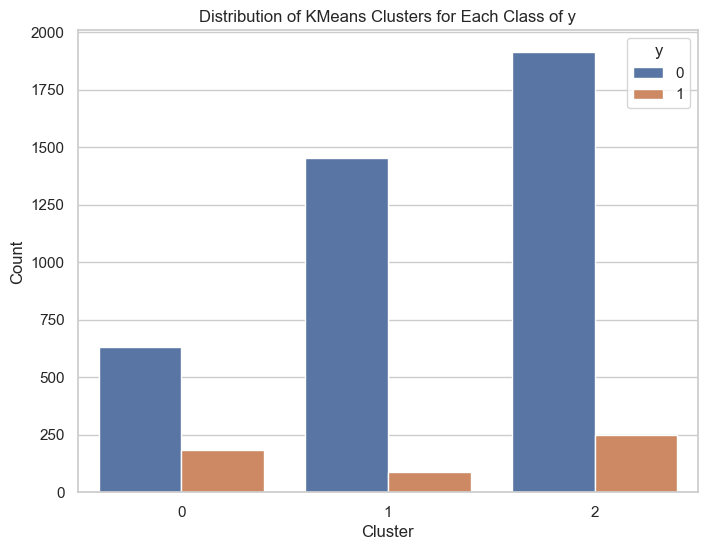

In [273]:
# Assuming 'Cluster' column is in your dataframe with KMeans results
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', hue='y', data=test_customers)
plt.title("Distribution of KMeans Clusters for Each Class of y")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [274]:
# Group the data by 'Cluster' and calculate the ratio of 1s in each cluster
cluster_ratios = test_customers.groupby('cluster')['y'].mean()

# Find the cluster with the highest ratio of 1s
max_cluster = cluster_ratios.idxmax()
max_ratio = cluster_ratios.max()

# Print the result
print(f"Cluster {max_cluster} has the highest ratio of 1s with a ratio of {max_ratio:.4f}")


Cluster 0 has the highest ratio of 1s with a ratio of 0.2255


In [332]:
test_customers['cluster'].value_counts(normalize=True)

2    0.478655
1    0.340854
0    0.180491
Name: cluster, dtype: float64

In [294]:
test_summary = test_customers.groupby('cluster').mean()

In [295]:
# Print each row of the summary
for index, row in test_summary.iterrows():
    print(f"Cluster {index}:")
    print(row)
    print("\n")

Cluster 0:
age                                41.562500
education                           1.296569
job_admin.                          0.132353
job_blue-collar                     0.186275
job_entrepreneur                    0.028186
job_housemaid                       0.022059
job_management                      0.227941
job_retired                         0.060049
job_self-employed                   0.034314
job_services                        0.075980
job_student                         0.026961
job_technician                      0.172794
job_unemployed                      0.025735
job_unknown                         0.007353
marital_divorced                    0.104167
marital_married                     0.602941
marital_single                      0.292892
default                             0.006127
balance                          1639.671569
housing                             0.632353
loan                                0.121324
campaign                            2.015931

### use manual assignment 

In [ ]:
# Assuming the model has already been trained and high-value group is identified
high_value_cluster = 0  # Cluster 0
high_value_centroid = kmeans.cluster_centers_[high_value_cluster]
print(high_value_centroid)

[ 1.55763452e-03  6.93884007e-02  5.47971181e-02 -4.70858819e-02
 -3.15712847e-02 -5.51764716e-02  2.92771347e-02  4.09229144e-02
 -4.79888891e-03 -2.19693845e-02  9.66877124e-02 -1.45668329e-02
 -1.80198577e-02 -2.98154195e-02 -7.44698931e-03 -5.57767332e-02
  6.58959962e-02 -8.35855352e-02  6.39564449e-02  1.34866332e-01
 -6.62250344e-02 -2.28414637e-01  5.59650997e-01  4.96295841e-02
 -6.17243800e-01  1.56123471e+00  9.22234658e-01  8.32575753e-01
 -2.11568862e+00  1.84171411e+00  1.12763353e+00]


In [276]:
from sklearn.metrics.pairwise import euclidean_distances,cosine_similarity

# compute using euclidean distance
distances = euclidean_distances(data_scaled_test, [high_value_centroid])
test_customers['distances_to_high_value'] = distances

# Compute the cosine similarity (higher value indicates similarity)
similarity = cosine_similarity(data_scaled_test, [high_value_centroid])
test_customers['similarity_to_high_value'] = similarity


/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/1404502257.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_customers['distances_to_high_value'] = distances
/var/folders/8v/1ymqzx0d0rs6zflszs3946nr0000gn/T/ipykernel_70559/1404502257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_customers['similarity_to_high_value'] = similarity


In [279]:
import numpy as np

# Compute distances for known high-value training customers
high_value_distances = euclidean_distances(data_scaled[banking_marketing_train_clustered_with_y['Cluster'] == 0], [high_value_centroid])
high_value_similarity = cosine_similarity(data_scaled[banking_marketing_train_clustered_with_y['Cluster'] == 0], [high_value_centroid])

# Choose a threshold (e.g., 95th percentile of known high-value distances)
threshold = np.percentile(high_value_distances, 95)
similarity_threshold = np.percentile(high_value_similarity, 95)

print("Optimal Distance Threshold:", threshold)
print("Optimal Similarity Threshold:", similarity_threshold)

Optimal Distance Threshold: 8.792762218484834
Optimal Similarity Threshold: 0.7351185052882223


In [284]:
# Assign high-value segment labels based on thresholds
test_customers['high_value_segment_distance'] = (test_customers['distances_to_high_value'] < threshold).astype(int)
test_customers['high_value_segment_similarity'] = (test_customers['similarity_to_high_value'] > similarity_threshold).astype(int)

In [285]:
test_customers.head()

,age,education,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,poutcome_success,poutcome_unknown,pdays,previous,y,cluster,distances_to_high_value,similarity_to_high_value,high_value_segment_distance,high_value_segment_similarity
0,30,0,0,0,0,0,0,0,0,0,...,0,1,-1,0,0,2,7.927392,-0.099464,1,0
1,33,1,0,0,0,0,0,0,0,1,...,0,0,339,4,0,0,5.200564,0.669814,1,0
2,35,2,0,0,0,0,1,0,0,0,...,0,0,330,1,0,0,4.084693,0.719872,1,0
3,30,2,0,0,0,0,1,0,0,0,...,0,1,-1,0,0,1,6.537297,-0.290298,1,0
4,59,1,0,1,0,0,0,0,0,0,...,0,1,-1,0,0,1,6.202772,-0.320107,1,0


In [ ]:
# analyse
high_value_count = test_customers['high_value_segment'].sum()
total_customers = test_customers.shape[0]
print(f"Percentage of high-value customers in test set: {high_value_count / total_customers * 100}%")


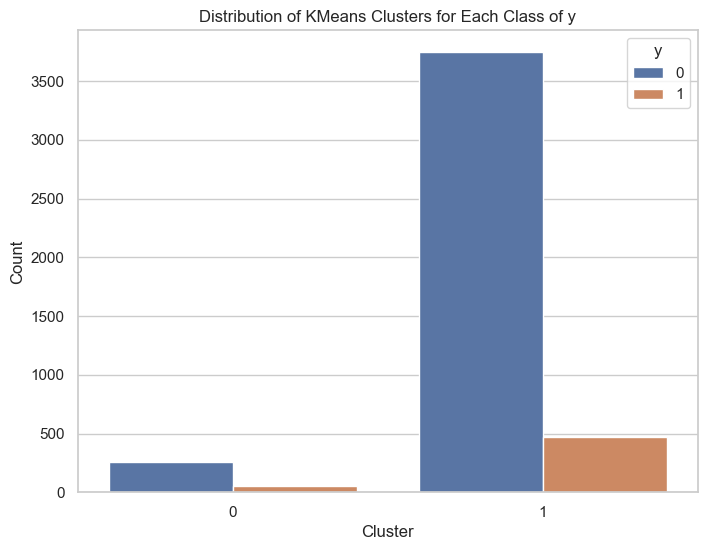

In [286]:
# Assuming 'Cluster' column is in your dataframe with KMeans results
plt.figure(figsize=(8, 6))
sns.countplot(x='high_value_segment_distance', hue='y', data=test_customers)
plt.title("Distribution of KMeans Clusters for Each Class of y")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [291]:
# Step 1: Get the subset of test customers whose distance to high-value is 1
indices = test_customers['high_value_segment_distance'] == 1
subset_customers = test_customers[indices]

# Step 2: Filter customers in this subset who are high-value (y == 1)
high_value_customers = subset_customers[subset_customers['y'] == 1]

# Step 3: Calculate the ratio of high-value customers in this subset
high_value_ratio = high_value_customers.shape[0] / subset_customers.shape[0]

print("High-Value Customer Ratio in the Subset:", high_value_ratio)


High-Value Customer Ratio in the Subset: 0.1110847377165915


conclustion:
financial stability is the most important feature for deciding high-value group, and they should be priotised
Cluster 0 customers are generally wealthier, with higher average balances and a greater likelihood of having housing loans compared to the general population. They are slightly younger and tend to be more responsive to cellular contact, though they have a higher proportion of failed outcomes and fewer responses to campaigns. These customers also have a more persistent history of contact with the bank, as indicated by higher numbers of previous contacts and longer gaps between interactions. While their job and marital status distributions are fairly similar to the broader population, Cluster 0 shows a slight tendency toward a higher proportion of single individuals.

The test cluster 0 shows higher average balances (1639.67 vs. 1557.00) and a lower loan rate (12.13% vs. 13.59%) compared to the training cluster, suggesting a more affluent group. Both clusters exhibit similar job and marital status distributions, with strong engagement through cellular contact. However, the test cluster has a slightly higher campaign success rate (22.55% vs. 18.31%) and is less similar to the high-value segment, as indicated by a higher distance (5.93 vs. 3.61) and lower similarity (0.56 vs. 0.57).


# Multi-Armed Bandit + Reinforcement Learning for Marketing Strategy Optimization

In [323]:
banking_marketing_train_rl = banking_marketing_train_encoded
banking_marketing_test_rl = banking_marketing_test_encoded

In [324]:
# Initialize the scaler
scaler = StandardScaler()

# Standardize the training data
xtrain = scaler.fit_transform(banking_marketing_train_rl.drop(columns=['y']))

# Do not standardize the target variable
ytrain = banking_marketing_train_rl['y'].values

# Standardize the test data using the parameters from the training set
xtest = scaler.transform(banking_marketing_test_rl.drop(columns=['y']))

# Do not standardize the target variable in the test set
ytest = banking_marketing_test_rl['y'].values

# Extract feature names for later use
features = banking_marketing_train_rl.drop(columns=['y']).columns

# Target variable (no need to standardize)
target = ['y']


## Multi-Armed Bandit: UCB1 - general exploration

In [344]:
np.random.seed(42)

class UCB1:
    def __init__(self, n_strategies):
        self.n = n_strategies  # Number of marketing strategies
        self.counts = np.zeros(n_strategies)  # Number of times each strategy is chosen
        self.values = np.zeros(n_strategies)  # Expected reward for each strategy

    def select_strategy(self):
        """Select strategy using UCB1 formula."""
        total_counts = sum(self.counts)
        if 0 in self.counts:
            return np.argmin(self.counts)  # Explore untested strategies

        ucb_values = self.values + np.sqrt(2 * np.log(total_counts) / self.counts)
        return np.argmax(ucb_values)  # Select the strategy with highest UCB score

    def update(self, chosen_strategy, reward, cost):
        """Update strategy reward estimates considering both reward and cost."""
        # Calculate the net reward (reward - cost)
        net_reward = reward - cost
        self.counts[chosen_strategy] += 1
        # Update the value estimate using the net reward (reward - cost)
        self.values[chosen_strategy] += (net_reward - self.values[chosen_strategy]) / self.counts[chosen_strategy]

# Initialize UCB1 for 3 strategies
ucb_agent = UCB1(n_strategies=3)

# Define cost for each strategy (e.g., personalization costs)
costs = [1, 1.84, 3]  # Example costs for strategies: Broad, Group-Based, AI-Based

# Simulate 1000 campaigns
for t in range(1000):
    strategy = ucb_agent.select_strategy()  # Choose best strategy
    # Simulate reward (could be based on conversion, retention, etc.)
    reward = np.random.uniform(0, 100)  # Simulated reward (random for example)
    cost = costs[strategy]  # Cost for the chosen strategy
    ucb_agent.update(strategy, reward, cost)

print("Final expected values:", ucb_agent.values)


Final expected values: [36.45401188 40.42871251 46.20384843]


## Reinforcement Learning: DQN - find optimal strategy

We treat the marketing campaign as a Markov Decision Process (MDP):

State (S): Customer features (age, job, marital status, etc.).
Actions (A): Which marketing strategy to use.
Reward (R): 1 if the customer subscribes, 0 otherwise.
Q-value (Q(S, A)): Expected success rate of using strategy A in state S.
We train a Deep Q-Network (DQN) to approximate Q(S, A) and select the best strategy.

cost:

Broad: 1
Group-Based: 0.18*3+0.34*1+0.48*2 = 1.84    (segment clients into 3 groups and apply different personalisation levels on each group)
AI-Based: 3

from clustering of test data: 
2    0.478655   - medium-value 
1    0.340854   - low-value (extent of personalisation has uncertain effect)
0    0.180491   - high-value

In [338]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

# Hyperparameters
STATE_SIZE = xtrain.shape[1]
ACTION_SIZE = 3  # Broad, Group-Based, AI-Based
GAMMA = 0.95  # Discount Factor
LR = 0.001  # Learning Rate
EPSILON = 1.0  # Initial exploration
EPSILON_DECAY = 0.98  # Smoother decay
EPSILON_MIN = 0.01
MEMORY_SIZE = 5000  # Increased memory for better experience replay
BATCH_SIZE = 64  # Larger batch size for stability

# Define Q-Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Experience Replay Memory
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def add(self, experience):
        self.memory.append(experience)

    def sample(self, batch_size):
        return random.sample(self.memory, min(batch_size, len(self.memory)))

# Q-Learning Agent
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = ReplayMemory(MEMORY_SIZE)
        self.epsilon = EPSILON  # Exploration rate
        self.model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=LR)
        self.loss_fn = nn.MSELoss()

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_size)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            return torch.argmax(self.model(state_tensor)).item()

    def train(self):
        if len(self.memory.memory) < BATCH_SIZE:
            return

        batch = self.memory.sample(BATCH_SIZE)
        states, actions, rewards, next_states = zip(*batch)

        states_tensor = torch.FloatTensor(states)
        actions_tensor = torch.LongTensor(actions).unsqueeze(1)
        rewards_tensor = torch.FloatTensor(rewards)
        next_states_tensor = torch.FloatTensor(next_states)

        q_values = self.model(states_tensor).gather(1, actions_tensor).squeeze()
        next_q_values = self.model(next_states_tensor).max(1)[0].detach()
        target_q_values = rewards_tensor + GAMMA * next_q_values

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

# Reward function
def calculate_reward(conversion, cost, retention_rate, clv, budget_left):
    profit = conversion * clv
    penalty = 0.2 * cost  # Reduced penalty to balance strategy
    budget_penalty = -10 if budget_left < 0 else 0
    return profit - penalty + (0.7 * retention_rate) + budget_penalty

# Extract state representation
def get_state(customer):
    return np.array(customer).flatten()

# Strategy-based retention rate
def calculate_strategy_based_retention_rate(action):
    return [np.random.uniform(0.2, 0.4), np.random.uniform(0.4, 0.6), np.random.uniform(0.6, 0.8)][action]

# Define strategies and costs
strategies = {0: 'Broad', 1: 'Group-Based', 2: 'AI-Based'} # Broad, Group-Based, AI-Based
costs = {0: 1, 1: 1.84, 2: 3} # personalisation cost
retention_rates = {0: 0.3, 1: 0.6, 2: 0.9}
campaign_rewards = {0: 50, 1: 55, 2: 60}

# initiate agent
agent = DQNAgent(STATE_SIZE, ACTION_SIZE)

num_campaigns = 10
total_rewards = {0: 0, 1: 0, 2: 0}
epsilon = 1.0  # Start with high exploration

for campaign in range(num_campaigns):
    print(f"\n🔹 Running Campaign {campaign + 1}...")

    # input budget amount
    ###
    budget = 10000 
    ###

    indices = np.arange(len(xtrain))
    np.random.shuffle(indices)  # Shuffle training order

    for idx in indices:
        customer = xtrain[idx]
        state = get_state(customer)

        action = agent.select_action(state) if np.random.rand() > epsilon else np.random.choice(list(strategies.keys()))
        
        cost = costs[action]
        retention_rate = calculate_strategy_based_retention_rate(action)

        conversion = ytrain[idx]
        clv = customer[-1] if conversion else 0

        reward = calculate_reward(conversion, cost, retention_rate, clv, budget)
        budget -= cost

        # Stop if budget is exhausted
        if budget <= 0:
            break

        next_state = get_state(xtrain[np.random.randint(len(xtrain))])  # Random next state
        agent.memory.add((state, action, reward, next_state))
        agent.train()

        # Update total rewards: Accumulate the individual reward - cost for each customer interaction
        total_rewards[action] += reward

    # Reduce epsilon (less exploration over time)
    epsilon = max(epsilon * EPSILON_DECAY, EPSILON_MIN)

# Select best strategy
best_strategy = max(total_rewards, key=total_rewards.get)
print(f"\n✅ Final Recommended Strategy after {num_campaigns} campaigns: {strategies[best_strategy]}")



🔹 Running Campaign 1...

🔹 Running Campaign 2...

🔹 Running Campaign 3...

🔹 Running Campaign 4...

🔹 Running Campaign 5...

🔹 Running Campaign 6...

🔹 Running Campaign 7...

🔹 Running Campaign 8...

🔹 Running Campaign 9...

🔹 Running Campaign 10...

✅ Final Recommended Strategy after 10 campaigns: Broad


In [337]:
# Assuming you have a trained agent

# Prepare for evaluation
test_rewards = {0: 0, 1: 0, 2: 0}  # Track total rewards for each strategy

# Run evaluation on test data
for idx in range(len(xtest)):  # Iterate over the test data
    customer = xtest[idx]  # Get customer data from the test set
    state = get_state(customer)  # Extract the state representation

    # **Use the trained model to select the best action**
    action = agent.select_action(state)  # Exploit the learned policy

    # Get cost, retention rate, and other necessary info for the selected action
    cost = costs[action]
    retention_rate = retention_rates[action]

    # Get actual conversion rate from ytest
    conversion = ytest[idx]  # Test data labels (converted or not)
    clv = customer[-1] if conversion else 0  # CLV is 0 if not converted

    # Calculate reward based on conversion, cost, retention, and CLV
    reward = calculate_reward(conversion, cost, retention_rate, clv, budget_left=0)  # Assuming no budget for simplicity
    test_rewards[action] += reward  # Accumulate rewards for each strategy

# Print the final evaluation metrics
print("Evaluation on Test Data:")
for action in strategies.keys():
    print(f"Strategy {strategies[action]}: Total Reward = {test_rewards[action]}")

# Optionally, you can calculate and print the average reward across all strategies
total_test_reward = sum(test_rewards.values())
avg_test_reward = total_test_reward / len(test_rewards)

print(f"Average Reward across all strategies: {avg_test_reward}")

# Select best strategy
best_strategy = max(test_rewards, key=test_rewards.get)
print(f"\n✅ Final Recommended Strategy: {strategies[best_strategy]}")


Evaluation on Test Data:
Strategy Broad: Total Reward = 14.939999999999726
Strategy Group-Based: Total Reward = 79.82000000000158
Strategy AI-Based: Total Reward = 44.76000000000093
Average Reward across all strategies: 46.50666666666742

✅ Final Recommended Strategy: Group-Based


In [ ]:
# # evaluation

# # Tracking metrics
# reward_history_test = []
# conversion_rates_test = []
# budget_utilization_test = []

# def evaluate_on_test(agent, x_test, y_test, budget_initial=1000):
#     """
#     Evaluates the performance of the trained agent on the test dataset.
#     """
#     total_reward = 0
#     total_conversions = 0
#     total_cost = 0
#     budget = budget_initial  # Set the initial budget
    
#     for idx, customer in x_test.iterrows():
#         state = get_state(customer)  # Get state representation from customer data
#         action = agent.select_action(state)  # Select the action (strategy)

#         # Get actual conversion rate from the test data
#         conversion = y_test.iloc[idx].values[0]  
#         cost = [1, 2, 3][action]  # Cost based on the selected strategy

#         # Simulate retention rate and CLV based on conversion
#         retention_rate = np.random.uniform(0.1, 0.5) if conversion else 0
#         clv = np.random.uniform(100, 500) if conversion else 0
        
#         reward = calculate_reward(conversion, cost, retention_rate, clv, budget)
#         budget -= cost  # Reduce the budget based on the selected strategy's cost

#         total_reward += reward
#         total_conversions += conversion
#         total_cost += cost
    
#     # Metrics for evaluation
#     conversion_rate = total_conversions / len(x_test)  # Conversion rate
#     cost_per_conversion = total_cost / total_conversions if total_conversions > 0 else float("inf")
#     budget_utilization = 1 - (budget / budget_initial)  # Budget utilization rate

#     print(f"Test Evaluation: Conversion Rate = {conversion_rate:.4f}, Cost per Conversion = {cost_per_conversion:.2f}, Budget Utilization = {budget_utilization:.2f}")
#     return total_reward, conversion_rate, cost_per_conversion, budget_utilization

# # Evaluate the model on test data
# test_reward, test_conversion_rate, test_cost_per_conversion, test_budget_utilization = evaluate_on_test(agent, xtest, ytest)

# # Track metrics (optional)
# reward_history_test.append(test_reward)
# conversion_rates_test.append(test_conversion_rate)
# budget_utilization_test.append(test_budget_utilization)


In [ ]:
# import matplotlib.pyplot as plt

# # Plot total reward
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 3, 1)
# plt.plot(reward_history, label="Total Reward", color='b')
# plt.xlabel("Episodes")
# plt.ylabel("Reward")
# plt.title("Reward per Episode")
# plt.legend()

# # Plot conversion rate
# plt.subplot(1, 3, 2)
# plt.plot(conversion_rates, label="Conversion Rate", color='g')
# plt.xlabel("Episodes")
# plt.ylabel("Conversion Rate")
# plt.title("Conversion Rate per Episode")
# plt.legend()

# # Plot budget utilization
# plt.subplot(1, 3, 3)
# plt.plot(budget_utilization, label="Budget Utilization", color='r')
# plt.xlabel("Episodes")
# plt.ylabel("Utilization (Fraction of Budget Spent)")
# plt.title("Budget Utilization Over Time")
# plt.legend()

# plt.tight_layout()
# plt.show()


# ab testing

In [301]:
banking_marketing_train_ab = banking_marketing_train_encoded
banking_marketing_test_ab = banking_marketing_test_encoded

In [ ]:
from scipy import stats


# Step 2: Separate the groups (contacted vs. not contacted)
treatment_group = banking_marketing_train_ab[banking_marketing_train_ab['pdays'] != -1]['y']  # Customers contacted
control_group = banking_marketing_train_ab[banking_marketing_train_ab['pdays'] == -1]['y']   # Customers not contacted

# Step 3: Calculate subscription rates (proportions)
subscription_rate_treatment = treatment_group.mean()
subscription_rate_control = control_group.mean()

print(f"Subscription rate for contacted customers: {subscription_rate_treatment:.2f}")
print(f"Subscription rate for non-contacted customers: {subscription_rate_control:.2f}")

# Step 4: Perform a proportion test (z-test) to compare the subscription rates
# Proportion test requires the observed number of successes (subscribed) and failures (not subscribed) in both groups.
success_treatment = treatment_group.sum()
failure_treatment = len(treatment_group) - success_treatment

success_control = control_group.sum()
failure_control = len(control_group) - success_control

# Combine the groups for z-test
n_treatment = len(treatment_group)
n_control = len(control_group)

# p1: proportion of successes in treatment group
p1 = success_treatment / n_treatment
# p2: proportion of successes in control group
p2 = success_control / n_control

# p_pool: pooled proportion (pooled success rate across both groups)
p_pool = (success_treatment + success_control) / (n_treatment + n_control)

# Standard error of the difference between proportions
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_treatment + 1 / n_control))

# Z-statistic for testing the difference in proportions
z_stat = (p1 - p2) / se

# Two-tailed p-value from the z-statistic
p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))

# Step 5: Output the results
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Step 6: Conclusion based on the p-value
if p_value < 0.05:
    print("There is a significant difference in subscription rates between contacted and non-contacted customers.")
else:
    print("There is no significant difference in subscription rates between contacted and non-contacted customers.")


Subscription rate for contacted customers: 0.23
Subscription rate for non-contacted customers: 0.09
Z-statistic: 35.565
P-value: 0.000
There is a significant difference in subscription rates between contacted and non-contacted customers.
